Si consideri il dataset clinico SUPPORT2, contenente informazioni demografiche, fisiologiche e di laboratorio
relative a pazienti ospedalizzati.

In [2]:
import pandas as pd
ds = pd.read_csv(".\dataset_esercitazione.csv", sep=',')
print(ds)

           age     sex            dzgroup             dzclass  num.co   edu  \
0     62.84998    male        Lung Cancer              Cancer       0  11.0   
1     60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2     52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3     42.38498  female        Lung Cancer              Cancer       2  11.0   
4     79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
...        ...     ...                ...                 ...     ...   ...   
9100  66.07300    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   
9101  55.15399  female               Coma                Coma       1  11.0   
9102  70.38196    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
9103  47.01999    male       MOSF w/Malig            ARF/MOSF       1  13.0   
9104  81.53894  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   

          income  scoma  charges      totcst  ...  

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\giova\AppData\Local\Temp\ipykernel_40448\674523165.py:2: SyntaxWarning: invalid escape sequence '\d'
  ds = pd.read_csv(".\dataset_esercitazione.csv", sep=',')


Dopo aver caricato i dati, rimuovere le variabili di outcome e prognosi per
evitare fenomeni di data leakage e selezionare una variabile target (ad esempio dzgroup).

In [3]:
#variabili di outcome: death, dts, surv2m, surv6m, hospdead
#variabili di prognosi: sps, aps, surv, prg2m, prg6m
#variabile target: dzgroup

X = ds.drop(columns=['death', 'dzgroup', 'dzclass', 'hday', 'dnrday', 'surv2m', 'surv6m', 'sps', 'aps', 'prg2m', 'prg6m', 'dnr', 'charges', 'totcst', 'totmcst', 'avtisst'])
y = ds['death']

Suddividere il dataset in training set (95%) e test set (5%) utilizzando un campionamento stratificato rispetto
alla variabile target («death»), in modo da preservare la distribuzione delle classi.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, stratify=y)

Gestire i dati mancanti applicando imputazione con mediana per le variabili numeriche e con un valore
costante (ad esempio "Unknown") per quelle categoriche; successivamente codificare le variabili categoriche
tramite Ordinal Encoding.

In [5]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

cat_values = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
num_values = X_train.select_dtypes(include=['number']).columns.tolist()

#per gestire i dati mancanti
report_missing = X_train.isnull().sum() / len(X_train) * 100
print(report_missing)

#contiamo le colonne con i dati mancanti
nan_columns = report_missing[report_missing > 0].index.tolist()
missing_cat = [col for col in nan_columns if col in cat_values]
missing_num = [col for col in nan_columns if col in num_values]

#impostiamo l'imputazione per variabili numeriche e categoriche
if len(missing_num) > 0:
    imputer_num = SimpleImputer(strategy='median')
    X_train[missing_num] = imputer_num.fit_transform(X_train[missing_num])
    X_test[missing_num] = imputer_num.transform(X_test[missing_num])
if len(missing_cat) > 0:
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
    X_train[missing_cat] = imputer_cat.fit_transform(X_train[missing_cat])
    X_test[missing_cat] = imputer_cat.transform(X_test[missing_cat])

#encoding per variabili categoriche
#eventuale controllo di esistenza
encoder_cat = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-5)
X_train[cat_values] = encoder_cat.fit_transform(X_train[cat_values])
X_test[cat_values] = encoder_cat.transform(X_test[cat_values])

age          0.000000
sex          0.000000
num.co       0.000000
edu         18.013643
income      32.859290
scoma        0.011562
race         0.474043
diabetes     0.000000
dementia     0.000000
ca           0.000000
meanbp       0.011562
wblc         2.277720
hrt          0.011562
resp         0.011562
temp         0.011562
pafi        25.737079
alb         37.125679
bili        28.754769
crea         0.728408
sod          0.011562
ph          25.297722
glucose     49.335183
bun         47.693375
urine       53.324084
adlp        61.914672
adls        31.587467
adlsc        0.000000
dtype: float64


Applicare lo scaling delle feature numeriche tramite z-scoring, quindi calcolare e analizzare la matrice di
correlazione, individuando eventuali coppie di variabili altamente correlate e discutendo la presenza di
multicollinearità.

               age       sex    num.co       edu    income     scoma  \
age       1.000000 -0.047119  0.125364 -0.115784  0.061723  0.008361   
sex      -0.047119  1.000000  0.047236 -0.006122 -0.087346 -0.039196   
num.co    0.125364  0.047236  1.000000 -0.100521  0.084816 -0.125482   
edu      -0.115784 -0.006122 -0.100521  1.000000 -0.202820  0.003460   
income    0.061723 -0.087346  0.084816 -0.202820  1.000000  0.017398   
scoma     0.008361 -0.039196 -0.125482  0.003460  0.017398  1.000000   
race      0.164615  0.043233  0.008922  0.091269 -0.128306 -0.055095   
diabetes  0.093738 -0.045047  0.388290 -0.064546  0.032128 -0.002158   
dementia  0.192881 -0.028826  0.141031 -0.010146  0.046912  0.071493   
ca        0.043236  0.003138  0.166316 -0.042372  0.058264  0.121847   
meanbp   -0.040743 -0.009163 -0.014449 -0.031515 -0.003559 -0.037046   
wblc      0.002605 -0.020951 -0.014970 -0.002570  0.010746  0.082386   
hrt      -0.128304 -0.012209 -0.062575 -0.006190  0.000665  0.02

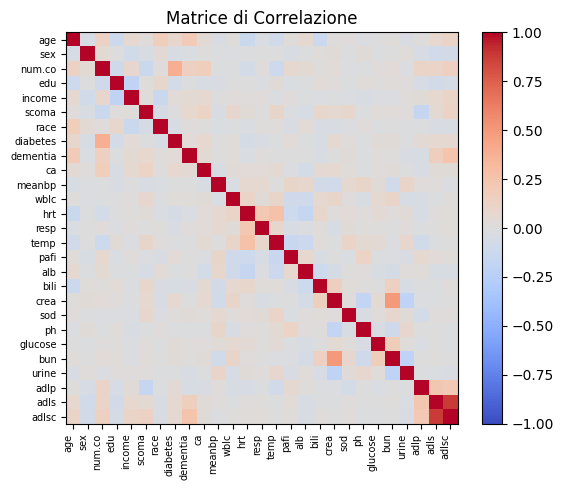

adls   adlsc    0.880326
adlsc  adls     0.880326
dtype: float64
Rilevate coppie con correlazione superiore a 0.8
Correlazione di 0.8803263409671356 per la coppia [adls, adlsc]


In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plot
import numpy as np

scaler = StandardScaler()
#applichiamo lo scaling delle feature numeriche tramite z-scoring
X_train[num_values] = scaler.fit_transform(X_train[num_values])
X_test[num_values] = scaler.transform(X_test[num_values])

#calcoliamo la matrice di correlazione su X_train (feature numeriche + feature categoriche dopo l'encoding)
corr_matrix = X_train.corr()
print(corr_matrix)
#analisi matrice
corr_figure, graph_area = plot.subplots(figsize=(7, 5))  #figura e area di disegno
color_map = graph_area.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)  #mappa di calore
corr_figure.colorbar(color_map, fraction=0.04, pad=0.04)  #scala colore

var_num = np.arange(len(corr_matrix.columns))  #etichette sugli assi
var_names = corr_matrix.columns

graph_area.set_xticks(var_num)
graph_area.set_xticklabels(var_names, rotation=90, ha='right', fontsize=7)  #nomi alle tacche degli assi
graph_area.set_yticks(var_num)
graph_area.set_yticklabels(var_names, fontsize=7)

plot.title("Matrice di Correlazione")
plot.tight_layout()
plot.show()  #stampa grafico matrice

#analisi multicollinearità
rel_threshold = 0.8
corr_pairs = corr_matrix.unstack().sort_values(key=abs)
corr_pairs = corr_pairs[corr_pairs != 1.0]  #eliminiamo l'autocorrelazione
related_pairs = corr_pairs[abs(corr_pairs) > rel_threshold]  #le coppie altamente correlate avranno correlazione maggiore della soglia
print(related_pairs)

var_to_remove = set()  #impostiamo un set per non avere duplicati
if not related_pairs.empty:
    print(f'Rilevate coppie con correlazione superiore a {rel_threshold}')
    for i, value in related_pairs[::2].items():
        var1, var2 = i
        print(f'Correlazione di {value} per la coppia [{var1}, {var2}]')
        var_to_remove.add(var2)  #scegliamo arbitrariamente di rimuovere la seconda variabile
else:
    print('Nessuna correlazione critica rilevata')

Gestire la multicollinearità mediante rimozione di feature ridondanti o tramite una trasformazione lineare (ad
esempio PCA), e infine applicare un metodo di selezione delle feature per identificare le variabili più rilevanti,
commentando criticamente i risultati ottenuti.

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

#rimuoviamo le feature con più alta varianza rispetto al target
#if var_to_remove:  #controllo dimensione set
X_train_clean = X_train.drop(columns=list(var_to_remove))
X_test_clean = X_test.drop(columns=list(var_to_remove))

#feature selection (selezione delle feature più utili e meno correlate)
selector = SelectKBest(score_func=f_classif, k=10)  #ricaverò 10 feature tra quelle attualmente presenti

#addestriamo il selettore e trasformiamo il data set
X_train_final = selector.fit_transform(X_train_clean, y_train)
X_test_final = selector.transform(X_test_clean)

#stampa delle 10 feature risultanti
selected_features = X_train_clean.columns[selector.get_support()].tolist()
print(f"Le 10 feature più importanti sono: {selected_features}")

################################################################################
#selector.fit(X_tr, y_tr)

#feature_selezionate = X_tr.columns[selector.get_support()].tolist()
#print(f"Le {k_features} feature più importanti sono: {feature_selezionate}")

#X_tr_final = selector.transform(X_tr)
#X_te_final = selector.transform(X_te)
################################################################################

Le 10 feature più importanti sono: ['age', 'sex', 'num.co', 'scoma', 'dementia', 'ca', 'meanbp', 'temp', 'crea', 'adls']


Implementare un clustering dei punti del data set processato nelle fasi precedenti, utilizzando l’algoritmo
DBSCAN con una griglia di ricerca degli iper-parametri:
- MinPts = 5, 10, 20
- Eps = 0.5, 1.5, 2.0

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

minpts_values = [5, 10, 20]
eps_values = [0.5, 1.5, 2.0]

for minpts in minpts_values:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=minpts)  #di norma usare .fit(scaler.fit_transform(X_train))
        #dato che le feature sono già scalate e selezionate, usiamo .fit_predict(X_train_final)
        labels = db.fit_predict(X_train_final)  #etichette dei cluster

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  #calcoliamo il n. di cluster escludendo il rumore identificato con -1
        n_noise = list(labels).count(-1)
        if n_clusters > 1:  #silhouette score definito solo per due o più cluster
            score = silhouette_score (X_train_final, labels=labels)
        
        print (f"Risultati: Eps: {eps}, MinPts: {minpts}, N. cluster: {n_clusters}, N. noise: {n_noise}, Silhouette score: {score}\n")
        #se n_noise è troppo alto, allora eps è troppo basso o minpts è troppo alto
        #silhouette score --> vicino a 1: cluster densi e ben separati
        #                              0: cluster sovrapposti
        #                             -1: clustering errato

#Dall'analisi della grid search emerge che il dataset SUPPORT2 presenta una bassa densità locale,
#rendendo inefficaci valori di Epsilon bassi (0.5), che producono un eccessivo rumore (oltre 7000 punti isolati)
#o una frammentazione eccessiva (71 cluster).

#La configurazione ottimale è stata individuata con Eps=2.0 e MinPts=5, che massimizza il Silhouette Score (0.436)
#e riduce i punti di rumore a 129. Questo suggerisce che la struttura clinica dei pazienti è rilevabile solo con un raggio di vicinanza più ampio,
#portando alla formazione di due cluster principali che potrebbero riflettere la distinzione tra pazienti critici e stabili.

Risultati: Eps: 0.5, MinPts: 5, N. cluster: 68, N. noise: 7495, Silhouette score: -0.39785503726457044

Risultati: Eps: 1.5, MinPts: 5, N. cluster: 6, N. noise: 700, Silhouette score: 0.12444722059208012

Risultati: Eps: 2.0, MinPts: 5, N. cluster: 2, N. noise: 129, Silhouette score: 0.4365433842103097

Risultati: Eps: 0.5, MinPts: 10, N. cluster: 12, N. noise: 8314, Silhouette score: -0.34258455859778236

Risultati: Eps: 1.5, MinPts: 10, N. cluster: 3, N. noise: 1026, Silhouette score: 0.15654587610373505

Risultati: Eps: 2.0, MinPts: 10, N. cluster: 3, N. noise: 217, Silhouette score: 0.3378413936726805

Risultati: Eps: 0.5, MinPts: 20, N. cluster: 1, N. noise: 8628, Silhouette score: 0.3378413936726805

Risultati: Eps: 1.5, MinPts: 20, N. cluster: 2, N. noise: 1345, Silhouette score: 0.29125768861987955

Risultati: Eps: 2.0, MinPts: 20, N. cluster: 2, N. noise: 328, Silhouette score: 0.41917861697683767



Stampare l’accuracy del modello di clustering sul training set e sul test set. Valuta la purezza del clustering.

In [9]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import contingency_matrix
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

optimal_dbscan = DBSCAN(eps=2.0, min_samples=5)  #consideriamo il DBSCAN ottimale ricavato nel punto precedente
labels_train = optimal_dbscan.fit_predict(X_train_final)  #calcoliamo le etichette di train

#ora dobbiamo per forza creare un "ponte" per il TEST set, poichè DBSCAN non ha un metodo .predict()
#usiamo un KNN per assegnare i nuovi punti ai cluster esistenti
knn_bridge = KNeighborsClassifier(n_neighbors=1)
noiseless = labels_train != -1  #consideriamo i punti che non sono rumore
knn_bridge.fit(X_train_final[noiseless], labels_train[noiseless])

labels_test = knn_bridge.predict(X_test_final)  #possiamo così predire i cluster sul TEST

#calcolo di accuracy e purezza
def purity_computation(y_true, cluster_labels):
    c_matrix = contingency_matrix(y_true, cluster_labels)  #costruiamo la matrice di incrocio tra le classi reali e i cluster
    #sommiamo ora il numero di elementi della classe dominante per ogni cluster
    return np.sum(np.max(c_matrix, axis=0)) / np.sum(c_matrix)

#train set
accuracy_train = adjusted_rand_score(y_train, labels_train)  #adjusted random index; se vicino a 1, il clustering ha riscoperto esattamente chi muore e chi no
purity_train = purity_computation(y_train, labels_train)
print(f"Train - Accuracy: {accuracy_train}, Purezza: {purity_train}")
#test set
accuracy_test = adjusted_rand_score(y_test, labels_test)
purity_test = purity_computation(y_test, labels_test)
print(f"Test - Accuracy: {accuracy_test}, Purezza: {purity_test}")



#I risultati mostrano un Adjusted Rand Index (ARI) prossimo allo zero (e leggermente negativo), 
#indicando che la struttura di densità individuata da DBSCAN non è correlata alla variabile di outcome death.

#La purezza di circa 0.68, sebbene apparentemente discreta, riflette in realtà la distribuzione sbilanciata
#del dataset originale (dove i sopravvissuti sono la maggioranza). Il fatto che l'ARI sia quasi nullo conferma che
#i cluster formati non sono in grado di discriminare tra pazienti deceduti e sopravvissuti.

Train - Accuracy: -0.014483509830409295, Purezza: 0.6810035842293907
Test - Accuracy: -0.024477933275795127, Purezza: 0.6820175438596491


Implementare un clustering dei punti del dataset processato nelle fasi precedenti, utilizzando un secondo algoritmo di clustering. La selezione dell’algoritmo deve essere coerente con la natura del dato. Valuta la purezza del clustering.

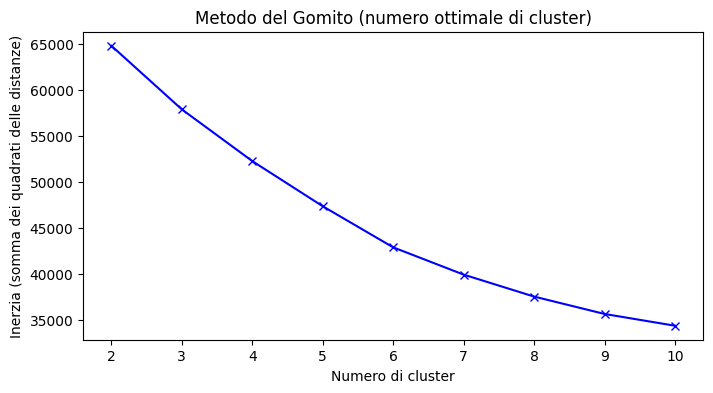

KMeans Train - Accuracy: 9.946093943511684e-05, Purezza: 0.6810035842293907
KMeans Test - Accuracy: -0.011409465189382972, Purezza: 0.6820175438596491


In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plot

#il KMeans è l'alternativa std più solida al DBSCAN, poichè eliminando il rumore aumenta la purezza
inerzia = []
for n in range(2, 11):
    km = KMeans(n_clusters=n, n_init=10, random_state=42)
    km.fit(X_train_final)  #addestramento del modello per apprendere dove si trovano i centri dei cluster
    inerzia.append(km.inertia_)  #inerzia: somma delle distanze al quadrato tra ogni paziente e il centro del suo cluster, indica quanto i cluster sono "stretti"

#utilizzo ora il metodo del Gomito per determinare il numero ottimale di cluster da usare
plot.figure(figsize=(8, 4))
plot.plot(range(2, 11), inerzia, 'bx-')
plot.xlabel("Numero di cluster")
plot.ylabel("Inerzia (somma dei quadrati delle distanze)")
plot.title("Metodo del Gomito (numero ottimale di cluster)")
plot.show()


#in base al grafico il numero ottimale di cluster da usare è 3
km_final = KMeans(n_clusters=3, n_init=10, random_state=42)  #calcoliamo il KMeans finale e determiniamo i cluster di train e di test
labels_train_km = km_final.fit_predict(X_train_final)
labels_test_km = km_final.predict(X_test_final)

#calcolo accuracy e purezza
accuracy_train_km = adjusted_rand_score(y_train, labels_train_km)
purity_train_km = purity_computation(y_train, labels_train_km)
print(f"KMeans Train - Accuracy: {accuracy_train_km}, Purezza: {purity_train_km}")

accuracy_test_km = adjusted_rand_score(y_test, labels_test_km)
purity_test_km = purity_computation(y_test, labels_test_km)
print(f"KMeans Test - Accuracy: {accuracy_test_km}, Purezza: {purity_test_km}")



#Il confronto tra i due algoritmi evidenzia che, per il dataset SUPPORT2, il K-Means (k=3) risulta marginalmente più coerente rispetto al DBSCAN,
#come dimostrato dal passaggio da un ARI negativo a uno positivo (0.0009).

#Tuttavia, entrambi i modelli faticano a discriminare la variabile death. La purezza costante a 0.68 suggerisce che
#i modelli tendono a raggruppare i pazienti in un unico cluster principale che riflette semplicemente la prevalenza
#della classe maggioritaria (i sopravvissuti).

#In conclusione, la natura del dato clinico SUPPORT2, caratterizzata da classi fortemente sovrapposte nello spazio delle feature,
#rende il clustering non supervisionato uno strumento poco efficace per la previsione della mortalità,
#suggerendo la necessità di modelli supervisionati o di una diversa trasformazione delle feature (es. PCA).

Esegui la comparazione delle performance utilizzando l’etichetta «death» con criteri di valutazione esterni.

In [18]:
import pandas as pd

comparazione = pd.DataFrame({
    'Metrica': ['ARI Train', 'ARI test', 'Purezza'],
    'DBSCAN (Eps 2.0, MinPts 5)': [accuracy_train, accuracy_test, purity_test],
    'K-Means (k=3)': [accuracy_train_km, accuracy_test_km, purity_test_km]
})

print("Comparazione finale delle performace")
print(comparazione)

Comparazione finale delle performace
     Metrica  DBSCAN (Eps 2.0, MinPts 5)  K-Means (k=3)
0  ARI Train                   -0.014484       0.000099
1   ARI test                   -0.024478      -0.011409
2    Purezza                    0.682018       0.682018
